# CHECK ENVIRONMENT SELECT KERNEL

In [26]:
import sys
print(sys.executable)

/Users/youshaabdullah/VSCode_Projects/Ionosphere_GNSS/GNSS/bin/python


# STEP 1 (A) — LOAD AND PREPROCESS GNSS VTEC

---

## 🌍 Data Source

<div style="padding:10px; border-left:5px solid #2E86C1; background-color:#EAF2F8;">
<b>VTEC Data Acquired From:</b><br>
<a href="https://arplsrv.ictp.it" target="_blank">ICTP Calibrated GNSS TEC Service</a>
</div>

---


In [27]:
import pandas as pd
# Import pandas library for dataframe/table operations

import numpy as np
# Import NumPy for numerical and mathematical operations

import glob
# Import glob to search files using filename patterns

import os
# Import os for file and directory handling

import matplotlib.pyplot as plt
# Import matplotlib for plotting graphs


# ============================================================
# STEP 1 — Load all daily files
# ============================================================

file_path = '/Users/youshaabdullah/VSCode_Projects/Ionosphere_GNSS/Data_Preprocessed/bako_14/'
# Folder containing all GNSS ionosphere files

all_files = sorted([
    # Create sorted list of all matching files

    f for f in glob.glob(os.path.join(file_path, 'bakoF3_*.14A'))
    # Search all files matching pattern bakoF3_*.14A

    if os.path.isfile(f)
    # Keep only valid files
])
# Store all file paths into list

print(f"Total files found : {len(all_files)}")
# Print total number of files found

print(f"First file        : {os.path.basename(all_files[0])}")
# Print first filename only

print(f"Last file         : {os.path.basename(all_files[-1])}")
# Print last filename only


# ============================================================
# STEP 2 — Single-day loader
# ============================================================

def load_day(fp):
    # Function to load one day's GNSS file

    basename = os.path.basename(fp)
    # Extract filename from full path

    day_num = int(basename.split('_')[1].split('.')[0])
    # Extract day number from filename

    try:
        # Attempt to load data file

        df = pd.read_csv(
            # Read file into dataframe

            fp,
            # File path

            sep=r'\s+',
            # Use whitespace as separator

            skiprows=5,
            # Skip first 5 header lines

            names=[
                'Time',
                'PRN',
                'PP',
                'Az',
                'El',
                'Lon',
                'Lat',
                'TEC'
            ]
            # Assign column names manually
        )

    except Exception as e:
        # Catch loading errors

        print(f"ERROR loading {basename}: {e}")
        # Print error message

        return None
        # Return None if loading fails


    df = df[df['PRN'] == 'Z00'].copy()
    # Keep only Z00 synthetic vertical TEC rows

    if len(df) == 0:
        # Check if no Z00 rows exist

        print(f"WARNING: No Z00 data in {basename}")
        # Print warning message

        return None
        # Skip empty files


    df = df.reset_index(drop=True)
    # Reset dataframe index


    # ============================================================
    # FEATURE ENGINEERING
    # ============================================================

    df['VTEC'] = df['TEC']
    # Copy TEC column into VTEC

    df['Day'] = day_num
    # Add day number column

    df['Time_Min'] = df['Time'] / 60.0
    # Convert time from seconds to minutes

    df['Time_h'] = df['Time'] / 3600.0
    # Convert time from seconds to hours


    # ============================================================
    # FULL DATETIME CREATION
    # ============================================================

    df['datetime'] = (
        # Create full UTC datetime column

        pd.to_datetime('2014-01-01')
        # Starting date of dataset

        +

        pd.to_timedelta(df['Day'] - 1, unit='D')
        # Add day offset

        +

        pd.to_timedelta(df['Time'], unit='s')
        # Add seconds-of-day
    )


    # ============================================================
    # CYCLICAL TIME FEATURES
    # ============================================================

    df['sin_time'] = np.sin(
        # Compute sine encoding of daily cycle

        2 * np.pi * df['Time_h'] / 24
        # Convert hour into cyclical angle
    )

    df['cos_time'] = np.cos(
        # Compute cosine encoding of daily cycle

        2 * np.pi * df['Time_h'] / 24
        # Convert hour into cyclical angle
    )


    return df
    # Return processed dataframe


# ============================================================
# STEP 3 — Load all files
# ============================================================

all_days = []
# List to store successful daily dataframes

failed = []
# List to store failed filenames

for fp in all_files:
    # Loop through all files

    day_df = load_day(fp)
    # Load single file

    if day_df is not None:
        # Check if loading succeeded

        all_days.append(day_df)
        # Store successful dataframe

    else:
        # If loading failed

        failed.append(os.path.basename(fp))
        # Store failed filename


print(f"Successfully loaded : {len(all_days)} days")
# Print successful load count

print(f"Failed/empty        : {len(failed)} files")
# Print failed file count


# ============================================================
# STEP 4 — Create annual dataframe
# ============================================================

df_year = pd.concat(
    # Concatenate all daily dataframes

    all_days,

    ignore_index=True
    # Reset row numbering
)


df_year = df_year.sort_values(
    # Sort dataset chronologically

    'datetime'
).reset_index(drop=True)
# Reset index after sorting

# ============================================================
# STEP 4B — CONTINUOUS FEATURE ENGINEERING
# ============================================================

# IMPORTANT:
# Features are computed AFTER concatenation
# so calculations continue across day boundaries

df_year['ROT'] = (

    df_year['VTEC'].diff()

    /

    df_year['Time_Min'].diff()
)
# Compute continuous Rate Of TEC change


df_year['ROTI_5min'] = df_year['ROT'].rolling(

    window=10,

    min_periods=1

).std()
# Compute rolling ROT variability over ~5 minutes


df_year['vtec_gradient'] = (

    df_year['VTEC'].diff(periods=10)

    / 5.0
)
# Compute VTEC gradient across continuous timeline


df_year['rot_abs'] = df_year['ROT'].abs()
# Compute absolute ROT magnitude


df_year['rot_std_local'] = df_year['ROT'].rolling(

    window=10,

    min_periods=1

).std()
# Compute local ROT variability


df_year['rot_accel'] = df_year['ROT'].diff()
# Compute ROT acceleration

# ============================================================
# STEP 4C — CLASSIFICATION LABELING
# ============================================================

roti = df_year['ROTI_5min']
# Store ROTI column temporarily


conditions = [

    roti < 0.015,
    # Quiet threshold

    (roti >= 0.015) & (roti < 0.045),
    # Weak threshold

    (roti >= 0.045) & (roti < 0.09),
    # Moderate threshold

    roti >= 0.09
    # Strong threshold
]


df_year['ionosphere_name'] = np.select(

    conditions,

    ['Quiet', 'Weak', 'Moderate', 'Strong'],

    default='Unknown'
)
# Convert ROTI thresholds into labels


df_year['target'] = df_year['ionosphere_name'].map({

    'Quiet'   : 0,

    'Weak'    : 1,

    'Moderate': 2,

    'Strong'  : 3
})
# Convert labels into ML target classes

# ============================================================
# STEP 5 — Dataset summary
# ============================================================

print(f"\nShape          : {df_year.shape}")
# Print dataframe dimensions

print(f"Days covered   : {df_year['Day'].nunique()}")
# Print number of unique days

print(
    f"Day range      : "
    f"{df_year['Day'].min()} "
    f"to "
    f"{df_year['Day'].max()}"
)
# Print minimum and maximum day number

print(f"Total samples  : {len(df_year):,}")
# Print total row count


print(f"\nColumns:\n{df_year.columns.tolist()}")
# Print all dataframe columns


print(
    f"\nFirst 3 rows:\n"
    f"{df_year.head(3)}"
)
# Print first 3 rows


# ============================================================
# STEP 6 — Missing day detection
# ============================================================

loaded_days = set(
    df_year['Day'].unique()
)
# Create set of loaded days


expected_days = set(

    range(

        df_year['Day'].min(),
        # Start day

        df_year['Day'].max() + 1
        # End day
    )
)
# Create expected continuous day range


missing_days = sorted(
    expected_days - loaded_days
)
# Find missing days


print(f"Expected days : {len(expected_days)}")
# Print total expected days

print(f"Loaded days   : {len(loaded_days)}")
# Print actual loaded days

print(f"Missing days  : {len(missing_days)}")
# Print missing day count

print(f"Missing list  : {missing_days}")
# Print missing day numbers


if failed:
    # Check if failed files exist

    print(f"Failed list   : {failed}")
    # Print failed filenames


# ============================================================
# STEP 7 — Sanity checks
# ============================================================

print("\nColumn list:")
# Print column title

print(df_year.columns.tolist())
# Print dataframe columns


print("\nROTI time range:")
# Print time range title

print(
    df_year['datetime'].min(),
    # Earliest timestamp

    "→",

    df_year['datetime'].max()
    # Latest timestamp
)


print("\nClass distribution across full year:")
# Print class distribution title

total = len(df_year)
# Store total sample count

for cls, count in df_year['ionosphere_name'].value_counts().items():
    # Loop through each class

    print(
        f"  {cls:<12}: "
        f"{count:6,} "
        f"({count/total*100:.2f}%)"
    )
    # Print class count and percentage


print("\nDays containing each class:")
# Print title

for cls in ['Quiet', 'Weak', 'Moderate', 'Strong']:
    # Loop through all classes

    n = df_year[
        df_year['ionosphere_name'] == cls
    ]['Day'].nunique()
    # Count unique days containing class

    print(f"  {cls:<12}: present on {n} days")
    # Print result


print("\nDay values sample check:")
# Print title

print(
    df_year['Day']
    .value_counts()
    .sort_index()
    .head(10)
)
# Print sample counts for first 10 days

Total files found : 311
First file        : bakoF3_001.14A
Last file         : bakoF3_365.14A
Successfully loaded : 311 days
Failed/empty        : 0 files

Shape          : (871192, 23)
Days covered   : 311
Day range      : 1 to 365
Total samples  : 871,192

Columns:
['Time', 'PRN', 'PP', 'Az', 'El', 'Lon', 'Lat', 'TEC', 'VTEC', 'Day', 'Time_Min', 'Time_h', 'datetime', 'sin_time', 'cos_time', 'ROT', 'ROTI_5min', 'vtec_gradient', 'rot_abs', 'rot_std_local', 'rot_accel', 'ionosphere_name', 'target']

First 3 rows:
   Time  PRN   PP    Az       El    Lon    Lat    TEC   VTEC  Day  ...  \
0     0  Z00  0.0  90.0  106.849 -6.491  23.18  23.18  23.18    1  ...   
1    30  Z00  0.0  90.0  106.849 -6.491  23.26  23.26  23.26    1  ...   
2    60  Z00  0.0  90.0  106.849 -6.491  23.35  23.35  23.35    1  ...   

   sin_time  cos_time   ROT  ROTI_5min  vtec_gradient  rot_abs  rot_std_local  \
0  0.000000  1.000000   NaN        NaN            NaN      NaN            NaN   
1  0.002182  0.999998  

In [28]:
# Clean up dataset by dropping unnecessary columns for modeling

df_year = df_year.drop(columns=[
    'Time', 'PRN', 'PP', 'Az', 'El', 'Lon', 'Lat', 'TEC',
    'Day', 'Time_Min', 'Time_h',
    'vtec_gradient', 'rot_abs', 'rot_std_local', 'rot_accel',
    'ionosphere_name', 'target'
], errors='ignore')

print("\nColumn list:")
# Print column title

print(df_year.columns.tolist())
# Print dataframe columns

df_year

# df_year.iloc[2860:2881]
# Print specified columns



Column list:
['VTEC', 'datetime', 'sin_time', 'cos_time', 'ROT', 'ROTI_5min']


,VTEC,datetime,sin_time,cos_time,ROT,ROTI_5min
0,23.18,2014-01-01 00:00:00,0.000000,1.000000,NaN,NaN
1,23.26,2014-01-01 00:00:30,0.002182,0.999998,0.16,NaN
2,23.35,2014-01-01 00:01:00,0.004363,0.999990,0.18,0.014142
3,23.43,2014-01-01 00:01:30,0.006545,0.999979,0.16,0.011547
4,23.52,2014-01-01 00:02:00,0.008727,0.999962,0.18,0.011547
...,...,...,...,...,...,...
871187,23.58,2014-12-31 23:57:30,-0.010908,0.999941,0.16,0.010328
871188,23.67,2014-12-31 23:58:00,-0.008727,0.999962,0.18,0.010328
871189,23.75,2014-12-31 23:58:30,-0.006545,0.999979,0.16,0.010328
871190,23.84,2014-12-31 23:59:00,-0.004363,0.999990,0.18,0.010541


# STEP 1 (B) — LOAD AND PREPROCESS Kp, Ap, Dst, F10.7

---

## 🌍 Data Source

<div style="padding:10px; border-left:5px solid #2E86C1; background-color:#EAF2F8;">
<b>VTEC Data Acquired From:</b><br>
<a href="https://www.ncei.noaa.gov/products/geomagnetic-indices" target="_blank">National Centers for
Environmental Information
(NATIONAL OCEANIC AND ATMOSPHERIC ADMINISTRATION)</a>
</div>

---


In [29]:
# ============================================================
# PART 1 — LOAD NOAA/GFZ GEOMAGNETIC DATA
# ============================================================

import pandas as pd
import numpy as np

# Path to NOAA/GFZ fixed-width Kp/AP dataset
kp_file = '/Users/youshaabdullah/VSCode_Projects/Ionosphere_GNSS/Data_Preprocessed/kp_ap_2014.txt'


# ============================================================
# STEP 1 — DEFINE FIXED WIDTH STRUCTURE
# ============================================================

colspecs = [
    (0,2),(2,4),(4,6),                         # YY MM DD
    (6,10),(10,12),                            # Bartels rotation info

    (12,14),(14,16),(16,18),(18,20),           # Kp1–Kp4
    (20,22),(22,24),(24,26),(26,28),           # Kp5–Kp8

    (28,31),                                   # Kp sum

    (31,34),(34,37),(37,40),(40,43),           # ap1–ap4
    (43,46),(46,49),(49,52),(52,55),           # ap5–ap8

    (55,58),(58,61),(61,62),                   # Ap, Cp, C9
    (62,65),(65,70),(70,71)                    # Sunspot, F10.7, qualifier
]

names = [
    'YY','MM','DD',
    'Bartels_Rotation','Bartels_Day',

    'Kp1','Kp2','Kp3','Kp4',
    'Kp5','Kp6','Kp7','Kp8',

    'Kp_sum',

    'ap1','ap2','ap3','ap4',
    'ap5','ap6','ap7','ap8',

    'Ap','Cp','C9',
    'Sunspot_Number','F10_7','Flux_Qualifier'
]


# ============================================================
# STEP 2 — LOAD RAW FILE
# ============================================================

kp_raw = pd.read_fwf(
    kp_file,
    colspecs=colspecs,
    names=names
)
# Reads fixed-width NOAA geomagnetic dataset (keeps NaN as-is)


# ============================================================
# STEP 3 — BUILD DATE COLUMN
# ============================================================

kp_raw['Year'] = 2000 + kp_raw['YY']
# Convert YY → full year (2014 etc.)

kp_raw['Date'] = pd.to_datetime({
    'year': kp_raw['Year'],
    'month': kp_raw['MM'],
    'day': kp_raw['DD']
})
# Build proper daily timestamp


# ============================================================
# STEP 4 — EXPAND TO 3-HOUR RESOLUTION (NOAA STANDARD)
# ============================================================

kp_rows = []

for _, row in kp_raw.iterrows():

    base_date = row['Date']
    # Daily reference timestamp

    kp_values = [
        row['Kp1'], row['Kp2'], row['Kp3'], row['Kp4'],
        row['Kp5'], row['Kp6'], row['Kp7'], row['Kp8']
    ]
    # 8 Kp values (3-hour resolution)

    ap_values = [
        row['ap1'], row['ap2'], row['ap3'], row['ap4'],
        row['ap5'], row['ap6'], row['ap7'], row['ap8']
    ]
    # 8 ap values (3-hour resolution)

    for i in range(8):

        kp_rows.append({

            'start_time': base_date + pd.Timedelta(hours=i*3),
            # Start of 3-hour window (used for merge_asof)

            'end_time': base_date + pd.Timedelta(hours=(i+1)*3),
            # End of 3-hour window (useful for validation)

            'Kp': kp_values[i] / 10.0,
            # Convert NOAA Kp (×10 scale) → real value

            'ap': ap_values[i],
            # 3-hour ap index

            'Daily_Ap': row['Ap'],
            # Daily Ap index (full-day geomagnetic activity)

            'Cp': row['Cp'],
            # Planetary daily character index

            'C9': row['C9'],
            # Additional geomagnetic index

            'F10_7': row['F10_7'],
            # Solar flux index

            'Sunspot_Number': row['Sunspot_Number'],
            # Solar activity indicator

            'Flux_Qualifier': row['Flux_Qualifier']
            # Data quality flag (important for filtering later)
        })


# Convert list to DataFrame
kp_df = pd.DataFrame(kp_rows)
# Final structured geomagnetic dataset (3-hour resolution)


# ============================================================
# STEP 5 — FINAL SORT (IMPORTANT FOR MERGE_ASOF)
# ============================================================

kp_df = kp_df.sort_values('start_time').reset_index(drop=True)
# Ensure chronological order for forward-fill merging


# ============================================================
# STEP 6 — VERIFY STRUCTURE
# ============================================================

print(kp_df.head())
# Show first rows

print("\nKp time range:")
print(kp_df['start_time'].min(), "→", kp_df['end_time'].max())
# Confirm full temporal coverage

           start_time            end_time   Kp  ap  Daily_Ap   Cp  C9  F10_7  \
0 2014-01-01 00:00:00 2014-01-01 03:00:00  0.7   3        11  0.6   3  154.3   
1 2014-01-01 03:00:00 2014-01-01 06:00:00  1.3   5        11  0.6   3  154.3   
2 2014-01-01 06:00:00 2014-01-01 09:00:00  2.0   7        11  0.6   3  154.3   
3 2014-01-01 09:00:00 2014-01-01 12:00:00  2.0   7        11  0.6   3  154.3   
4 2014-01-01 12:00:00 2014-01-01 15:00:00  3.7  22        11  0.6   3  154.3   

   Sunspot_Number  Flux_Qualifier  
0              87               0  
1              87               0  
2              87               0  
3              87               0  
4              87               0  

Kp time range:
2014-01-01 00:00:00 → 2015-01-01 00:00:00


## STEP 2 (B) — Merge Kp, Ap, Dst, F10.7 with df_year


In [30]:
# ============================================================
# STEP 0 — SORT BOTH DATASETS (REQUIRED FOR merge_asof)
# ============================================================

df_year = df_year.sort_values('datetime').reset_index(drop=True)
# Ensure ROTI dataset is time-ordered

kp_df = kp_df.sort_values('start_time').reset_index(drop=True)
# Ensure Kp dataset is time-ordered

# Drop unnecessary columns from df_year before merging (optional but cleaner)
df_year = df_year.drop(columns=[
    'start_time',
    'end_time',
    'Kp',
    'ap',
    'Daily_Ap',
    'Cp',
    'C9',
    'F10_7',
    'Sunspot_Number',
    'Flux_Qualifier'
], errors='ignore')

# ============================================================
# STEP 1 — FORWARD FILL MERGE (NO LOOP METHOD)
# ============================================================

df_year = pd.merge_asof(
    df_year,
    kp_df,
    left_on='datetime',
    right_on='start_time',
    direction='backward'
)
# Assigns each ROTI timestamp the most recent previous Kp/ap values


# ============================================================
# STEP 2 — CLEAN UNNECESSARY COLUMN (OPTIONAL)
# ============================================================

df_year = df_year.drop(columns=['end_time'])
# Remove interval end_time (not needed for ML)


# ============================================================
# STEP 3 — KEEP MISSING VALUES (IMPORTANT)
# ============================================================

# DO NOT drop NaN values
# We keep missing days for future imputation / modeling


# ============================================================
# STEP 4 — FINAL CHECK
# ============================================================

print(df_year.head(20))
# Show merged dataset sample


print("\nFinal dataset shape:")
print(df_year.shape)
# Show final size

     VTEC            datetime  sin_time  cos_time   ROT  ROTI_5min start_time  \
0   23.18 2014-01-01 00:00:00  0.000000  1.000000   NaN        NaN 2014-01-01   
1   23.26 2014-01-01 00:00:30  0.002182  0.999998  0.16        NaN 2014-01-01   
2   23.35 2014-01-01 00:01:00  0.004363  0.999990  0.18   0.014142 2014-01-01   
3   23.43 2014-01-01 00:01:30  0.006545  0.999979  0.16   0.011547 2014-01-01   
4   23.52 2014-01-01 00:02:00  0.008727  0.999962  0.18   0.011547 2014-01-01   
5   23.61 2014-01-01 00:02:30  0.010908  0.999941  0.18   0.010954 2014-01-01   
6   23.69 2014-01-01 00:03:00  0.013090  0.999914  0.16   0.010954 2014-01-01   
7   23.78 2014-01-01 00:03:30  0.015271  0.999883  0.18   0.010690 2014-01-01   
8   23.86 2014-01-01 00:04:00  0.017452  0.999848  0.16   0.010690 2014-01-01   
9   23.95 2014-01-01 00:04:30  0.019634  0.999807  0.18   0.010541 2014-01-01   
10  24.04 2014-01-01 00:05:00  0.021815  0.999762  0.18   0.010328 2014-01-01   
11  24.12 2014-01-01 00:05:3

In [31]:
# Clean up dataset by dropping unnecessary columns for modeling

df_year = df_year.drop(columns=['Flux_Qualifier','start_time'
    
], errors='ignore')

print("\nColumn list:")
# Print column title

print(df_year.columns.tolist())
# Print dataframe columns

df_year

# df_year.iloc[2860:2881]
# Print specified columns


Column list:
['VTEC', 'datetime', 'sin_time', 'cos_time', 'ROT', 'ROTI_5min', 'Kp', 'ap', 'Daily_Ap', 'Cp', 'C9', 'F10_7', 'Sunspot_Number']


,VTEC,datetime,sin_time,cos_time,ROT,ROTI_5min,Kp,ap,Daily_Ap,Cp,C9,F10_7,Sunspot_Number
0,23.18,2014-01-01 00:00:00,0.000000,1.000000,NaN,NaN,0.7,3,11,0.6,3,154.3,87
1,23.26,2014-01-01 00:00:30,0.002182,0.999998,0.16,NaN,0.7,3,11,0.6,3,154.3,87
2,23.35,2014-01-01 00:01:00,0.004363,0.999990,0.18,0.014142,0.7,3,11,0.6,3,154.3,87
3,23.43,2014-01-01 00:01:30,0.006545,0.999979,0.16,0.011547,0.7,3,11,0.6,3,154.3,87
4,23.52,2014-01-01 00:02:00,0.008727,0.999962,0.18,0.011547,0.7,3,11,0.6,3,154.3,87
...,...,...,...,...,...,...,...,...,...,...,...,...,...
871187,23.58,2014-12-31 23:57:30,-0.010908,0.999941,0.16,0.010328,1.7,6,8,0.4,2,129.2,65
871188,23.67,2014-12-31 23:58:00,-0.008727,0.999962,0.18,0.010328,1.7,6,8,0.4,2,129.2,65
871189,23.75,2014-12-31 23:58:30,-0.006545,0.999979,0.16,0.010328,1.7,6,8,0.4,2,129.2,65
871190,23.84,2014-12-31 23:59:00,-0.004363,0.999990,0.18,0.010541,1.7,6,8,0.4,2,129.2,65


In [32]:
df_year.iloc[2870:2891]
# Print specified columns

,VTEC,datetime,sin_time,cos_time,ROT,ROTI_5min,Kp,ap,Daily_Ap,Cp,C9,F10_7,Sunspot_Number
2870,24.42,2014-01-01 23:55:00,-0.021815,0.999762,0.100000,0.009661,3.0,15,11,0.6,3,154.3,87
2871,24.47,2014-01-01 23:55:30,-0.019634,0.999807,0.100000,0.009661,3.0,15,11,0.6,3,154.3,87
2872,24.51,2014-01-01 23:56:00,-0.017452,0.999848,0.080000,0.009661,3.0,15,11,0.6,3,154.3,87
2873,24.56,2014-01-01 23:56:30,-0.015271,0.999883,0.100000,0.009661,3.0,15,11,0.6,3,154.3,87
2874,24.61,2014-01-01 23:57:00,-0.013090,0.999914,0.100000,0.009661,3.0,15,11,0.6,3,154.3,87
2875,24.65,2014-01-01 23:57:30,-0.010908,0.999941,0.080000,0.009661,3.0,15,11,0.6,3,154.3,87
2876,24.70,2014-01-01 23:58:00,-0.008727,0.999962,0.100000,0.009661,3.0,15,11,0.6,3,154.3,87
2877,24.75,2014-01-01 23:58:30,-0.006545,0.999979,0.100000,0.009661,3.0,15,11,0.6,3,154.3,87
2878,24.79,2014-01-01 23:59:00,-0.004363,0.999990,0.080000,0.009661,3.0,15,11,0.6,3,154.3,87
2879,24.84,2014-01-01 23:59:30,-0.002182,0.999998,0.100000,0.009661,3.0,15,11,0.6,3,154.3,87


# STEP 1 (C) — LOAD AND PREPROCESS STORM INDICATORS
### Field magnitude average-nT(F8.2), BZ-nT(GSM)(F8.2), Speed-km/s(F8.1), Proton Density-n/cc(F7.2), Electric field-mV/m(F7.2), AE-index-nT(I6), SYM/H-nT(I6) 

---

## 🌍 Data Source

<div style="padding:10px; border-left:5px solid #2E86C1; background-color:#EAF2F8;">
<b>VTEC Data Acquired From:</b><br>
<a href="https://omniweb.gsfc.nasa.gov/form/omni_min.html?utm_source=chatgpt.com" target="_blank">NASA</a>
</div>

---


In [33]:
# ============================================================
# PART 2 — LOAD NASA OMNI SOLAR WIND / GEOMAGNETIC DATA
# ============================================================

# Path to OMNI fixed-width dataset
omni_file = '/Users/youshaabdullah/VSCode_Projects/Ionosphere_GNSS/Data_Preprocessed/omni_2014_data.txt'


# ============================================================
# STEP 1 — DEFINE COLUMN WIDTHS
# ============================================================

colspecs = [
    (0,4),     # Year
    (4,8),     # Day of year
    (8,11),    # Hour
    (11,14),   # Minute
    (14,22),   # Magnetic field magnitude
    (22,30),   # Bz GSM
    (30,38),   # Solar wind speed
    (38,45),   # Proton density
    (45,52),   # Electric field
    (52,58),   # AE index
    (58,64)    # SYM/H
]

names = [
    'Year',
    'DOY',
    'Hour',
    'Minute',
    'Bt',
    'Bz_GSM',
    'Solar_Wind_Speed',
    'Proton_Density',
    'Electric_Field',
    'AE_Index',
    'SYM_H'
]


# ============================================================
# STEP 2 — LOAD RAW FILE
# ============================================================

nasa_df = pd.read_fwf(
    omni_file,
    colspecs=colspecs,
    names=names
)
# Reads OMNI fixed-width dataset


# ============================================================
# STEP 3a — BUILD DATETIME COLUMN
# ============================================================

nasa_df['datetime'] = (
    pd.to_datetime(nasa_df['Year'], format='%Y') +
    pd.to_timedelta(nasa_df['DOY'] - 1, unit='D') +
    pd.to_timedelta(nasa_df['Hour'], unit='h') +
    pd.to_timedelta(nasa_df['Minute'], unit='m')
)
# Convert Year + DOY + Hour + Minute into timestamp

# ============================================================
# STEP 3b — REPLACE OMNI MISSING VALUE FLAGS
# ============================================================

nasa_df = nasa_df.replace({

    9999.99: np.nan,
    # Missing magnetic field values

    99999.9: np.nan,
    # Missing solar wind speed

    999.99: np.nan,
    # Missing proton density / electric field

    999999: np.nan,
    # Missing AE index

    99999: np.nan
    # Missing SYM/H
})

# ============================================================
# STEP 4 — SORT DATASET
# ============================================================

nasa_df = nasa_df.sort_values('datetime').reset_index(drop=True)
# Ensure chronological order

# Clean up dataset by dropping unnecessary columns for modeling

nasa_df = nasa_df.drop(columns=[
    'Year',
    'DOY',
    'Hour',
    'Minute'
], errors='ignore')

# ============================================================
# STEP 5 — VERIFY STRUCTURE
# ============================================================

print(nasa_df.head())
# Show first rows


print("\nOMNI time range:")
print(nasa_df['datetime'].min(), "→", nasa_df['datetime'].max())
# Confirm temporal coverage

     Bt  Bz_GSM  Solar_Wind_Speed  Proton_Density  Electric_Field  AE_Index  \
0  5.03   -1.22               NaN             NaN             NaN        17   
1  5.03   -1.21               NaN             NaN             NaN        15   
2  5.02   -1.18               NaN             NaN             NaN        14   
3  5.06   -1.52               NaN             NaN             NaN        13   
4  5.10   -1.43             386.2            5.93            0.55        13   

   SYM_H            datetime  
0     -1 2014-01-01 00:00:00  
1     -1 2014-01-01 00:01:00  
2     -1 2014-01-01 00:02:00  
3     -1 2014-01-01 00:03:00  
4     -1 2014-01-01 00:04:00  

OMNI time range:
2014-01-01 00:00:00 → 2014-12-31 23:59:00


## STEP 2 (C) — Merge STORM INDICATORS with df_year



In [35]:
# ============================================================
# PART 3 — MERGE NASA OMNI DATA WITH df_year
# ============================================================

# ============================================================
# STEP 0 — SORT BOTH DATASETS
# ============================================================

df_year = df_year.sort_values(

    'datetime'

).reset_index(drop=True)
# Ensure GNSS dataset is chronologically ordered


nasa_df = nasa_df.sort_values(

    'datetime'

).reset_index(drop=True)
# Ensure OMNI dataset is chronologically ordered


# ============================================================
# STEP 1 — REMOVE OLD OMNI COLUMNS (SAFE RE-RUN)
# ============================================================

df_year = df_year.drop(columns=[

    'Bt',
    'Bz_GSM',
    'Solar_Wind_Speed',
    'Proton_Density',
    'Electric_Field',
    'AE_Index',
    'SYM_H'

], errors='ignore')
# Prevent duplicate columns if notebook cell is re-run


# ============================================================
# STEP 2 — MERGE USING TIME-ALIGNED FORWARD FILL
# ============================================================

df_year = pd.merge_asof(

    df_year,

    nasa_df[[
        'datetime',
        'Bt',
        'Bz_GSM',
        'Solar_Wind_Speed',
        'Proton_Density',
        'Electric_Field',
        'AE_Index',
        'SYM_H'
    ]],
    # Keep only required OMNI features

    on='datetime',
    # Match using timestamp

    direction='backward'
    # Assign most recent previous OMNI observation
)
# Scientifically correct for time-series causal alignment


# ============================================================
# STEP 3 — FINAL VALIDATION
# ============================================================

print(df_year.head(20))
# Show merged sample


print("\nMerged dataset shape:")
# Print dataset size title

print(df_year.shape)
# Show final dataframe dimensions


print("\nMerged time range:")
# Print time range title

print(
    df_year['datetime'].min(),
    "→",
    df_year['datetime'].max()
)
# Verify temporal coverage


print("\nMissing values after merge:")
# Print NaN summary title

print(
    df_year[[
        'Bt',
        'Bz_GSM',
        'Solar_Wind_Speed',
        'Proton_Density',
        'Electric_Field',
        'AE_Index',
        'SYM_H'
    ]].isna().sum()
)
# Check missing OMNI parameters

# ============================================================
# STEP 4 — FINAL CHECK
# ============================================================

print(df_year)
# Show merged dataset sample


print("\nFinal dataset shape:")
print(df_year.shape)
# Show final size

     VTEC            datetime  sin_time  cos_time   ROT  ROTI_5min   Kp  ap  \
0   23.18 2014-01-01 00:00:00  0.000000  1.000000   NaN        NaN  0.7   3   
1   23.26 2014-01-01 00:00:30  0.002182  0.999998  0.16        NaN  0.7   3   
2   23.35 2014-01-01 00:01:00  0.004363  0.999990  0.18   0.014142  0.7   3   
3   23.43 2014-01-01 00:01:30  0.006545  0.999979  0.16   0.011547  0.7   3   
4   23.52 2014-01-01 00:02:00  0.008727  0.999962  0.18   0.011547  0.7   3   
5   23.61 2014-01-01 00:02:30  0.010908  0.999941  0.18   0.010954  0.7   3   
6   23.69 2014-01-01 00:03:00  0.013090  0.999914  0.16   0.010954  0.7   3   
7   23.78 2014-01-01 00:03:30  0.015271  0.999883  0.18   0.010690  0.7   3   
8   23.86 2014-01-01 00:04:00  0.017452  0.999848  0.16   0.010690  0.7   3   
9   23.95 2014-01-01 00:04:30  0.019634  0.999807  0.18   0.010541  0.7   3   
10  24.04 2014-01-01 00:05:00  0.021815  0.999762  0.18   0.010328  0.7   3   
11  24.12 2014-01-01 00:05:30  0.023996  0.999712  0

In [36]:
df_year.iloc[2870:2891]


,VTEC,datetime,sin_time,cos_time,ROT,ROTI_5min,Kp,ap,Daily_Ap,Cp,C9,F10_7,Sunspot_Number,Bt,Bz_GSM,Solar_Wind_Speed,Proton_Density,Electric_Field,AE_Index,SYM_H
2870,24.42,2014-01-01 23:55:00,-0.021815,0.999762,0.100000,0.009661,3.0,15,11,0.6,3,154.3,87,6.76,3.05,549.4,6.21,-1.68,130,-18
2871,24.47,2014-01-01 23:55:30,-0.019634,0.999807,0.100000,0.009661,3.0,15,11,0.6,3,154.3,87,6.76,3.05,549.4,6.21,-1.68,130,-18
2872,24.51,2014-01-01 23:56:00,-0.017452,0.999848,0.080000,0.009661,3.0,15,11,0.6,3,154.3,87,6.77,2.18,549.4,6.22,-1.20,114,-17
2873,24.56,2014-01-01 23:56:30,-0.015271,0.999883,0.100000,0.009661,3.0,15,11,0.6,3,154.3,87,6.77,2.18,549.4,6.22,-1.20,114,-17
2874,24.61,2014-01-01 23:57:00,-0.013090,0.999914,0.100000,0.009661,3.0,15,11,0.6,3,154.3,87,6.77,1.64,550.2,6.02,-0.90,129,-17
2875,24.65,2014-01-01 23:57:30,-0.010908,0.999941,0.080000,0.009661,3.0,15,11,0.6,3,154.3,87,6.77,1.64,550.2,6.02,-0.90,129,-17
2876,24.70,2014-01-01 23:58:00,-0.008727,0.999962,0.100000,0.009661,3.0,15,11,0.6,3,154.3,87,6.89,-1.97,550.4,6.05,1.08,135,-19
2877,24.75,2014-01-01 23:58:30,-0.006545,0.999979,0.100000,0.009661,3.0,15,11,0.6,3,154.3,87,6.89,-1.97,550.4,6.05,1.08,135,-19
2878,24.79,2014-01-01 23:59:00,-0.004363,0.999990,0.080000,0.009661,3.0,15,11,0.6,3,154.3,87,6.82,-2.06,547.6,5.94,1.13,145,-19
2879,24.84,2014-01-01 23:59:30,-0.002182,0.999998,0.100000,0.009661,3.0,15,11,0.6,3,154.3,87,6.82,-2.06,547.6,5.94,1.13,145,-19


# STEP 2 — CREATE TARGET CLASS

## Cell 7 — Missing day diagnostics

## STEP 3 — Load & Concatenate all files into one DataFrame

# STEP 4 — REMOVE NaN ROWS CAUSED BY DIFF + ROLLING


## ============================================================
## Data availability plot
## ============================================================


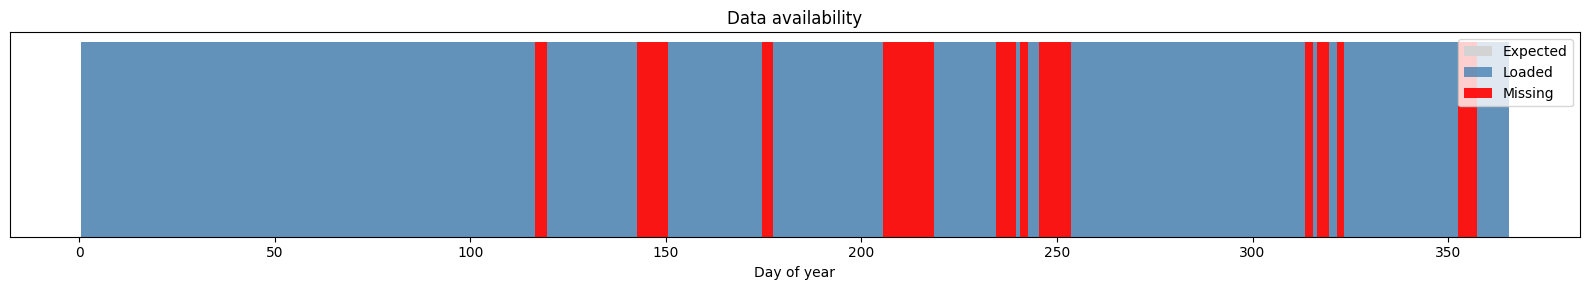

In [37]:
fig, ax = plt.subplots(figsize=(16, 3))

ax.bar(list(expected_days), [1]*len(expected_days),
       color='lightgray', width=1, label='Expected')
ax.bar(list(loaded_days), [1]*len(loaded_days),
       color='steelblue', width=1, label='Loaded', alpha=0.8)
if missing_days:
    ax.bar(missing_days, [1]*len(missing_days),
           color='red', width=1, label='Missing', alpha=0.9)

ax.set_xlabel('Day of year')
ax.set_title('Data availability')
ax.legend()
ax.set_yticks([])
plt.tight_layout()
plt.savefig('data_availability.png', dpi=150)
plt.show()

# STEP 5 — VIEW CLASS DISTRIBUTION

In [ ]:
# ============================================================
# Days with/without disturbances
# ============================================================
quiet_only_days = []
disturbed_days  = []

for day in sorted(loaded_days):
    has_disturbance = (df_year[df_year['Day'] == day]['target'] >= 2).any()
    if has_disturbance:
        disturbed_days.append(int(day))
    else:
        quiet_only_days.append(int(day))

print(f"Days with Moderate or Strong : {len(disturbed_days)}")
print(f"Days with Quiet/Weak only    : {len(quiet_only_days)}")
print(f"\nDisturbed days list: {disturbed_days}")


In [ ]:
# ============================================================
# Add seasonal cyclic features
# ============================================================
df_year['day_sin'] = np.sin(2 * np.pi * df_year['Day'] / 365)
df_year['day_cos'] = np.cos(2 * np.pi * df_year['Day'] / 365)

# Confirm they exist
print("day_sin and day_cos present:", 
      'day_sin' in df_year.columns and 'day_cos' in df_year.columns)

# ============================================================
# Local time sector flag
# Pre-dawn (0-6h) is where all Strong events live
# Giving SVM this context explicitly improves boundary learning
# ============================================================
df_year['is_predawn'] = ((df_year['Time_h'] >= 0) & 
                          (df_year['Time_h'] < 6)).astype(int)

# ============================================================
# VTEC normalized by daily maximum
# Removes inter-day absolute TEC differences
# so SVM learns relative ionospheric state, not absolute level
# ============================================================
daily_vtec_max = df_year.groupby('Day')['VTEC'].transform('max')
df_year['vtec_norm'] = df_year['VTEC'] / daily_vtec_max

# ============================================================
# Rolling VTEC variance (5 min window)
# Captures local TEC roughness independent of ROT direction
# ============================================================
df_year['vtec_var_5min'] = df_year.groupby('Day')['VTEC'].transform(
    lambda x: x.rolling(window=10, min_periods=1).var()
)

print(df_year[['Day','Time_h','is_predawn',
               'vtec_norm','vtec_var_5min']].head(10))
print("Seasonal features added: day_sin, day_cos")
print(df_year[['Day','day_sin','day_cos']].drop_duplicates().head(10))

In [ ]:
# ============================================================
# Annual ROTI overview plot
# ============================================================
daily_roti = df_year.groupby('Day')['ROTI_5min'].agg(['mean','std'])

fig, ax = plt.subplots(figsize=(16, 5))
ax.fill_between(daily_roti.index,
                daily_roti['mean'] - daily_roti['std'],
                daily_roti['mean'] + daily_roti['std'],
                alpha=0.3, color='steelblue', label='±1 std')
ax.plot(daily_roti.index, daily_roti['mean'],
        color='steelblue', lw=1.5, label='Daily mean ROTI')
ax.axhline(0.015, color='green',  linestyle='--', lw=1, label='Quiet|Weak')
ax.axhline(0.045, color='orange', linestyle='--', lw=1, label='Weak|Moderate')
ax.axhline(0.09,  color='red',    linestyle='--', lw=1, label='Moderate|Strong')
ax.set_xlabel('Day of year')
ax.set_ylabel('ROTI (TECU/min)')
ax.set_title('Daily mean ROTI')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('annual_roti_overview.png', dpi=150)
plt.show()

Seasonal class distribution plot

In [ ]:
df_year['Season'] = pd.cut(
    (df_year['Day'] % 365),
    bins=[0, 90, 181, 273, 365],
    labels=['DJF (Jan-Mar)', 'MAM (Apr-Jun)',
            'JJA (Jul-Sep)', 'SON (Oct-Dec)']
)

seasonal_pct = (
    df_year.groupby(['Season','ionosphere_name'])
    .size()
    .unstack(fill_value=0)
    .pipe(lambda x: x.div(x.sum(axis=1), axis=0) * 100)
)

print(seasonal_pct.round(2))

seasonal_pct[['Quiet','Weak','Moderate','Strong']].plot(
    kind='bar', figsize=(10, 6),
    color=['royalblue','green','orange','red'],
    alpha=0.85, edgecolor='white'
)
plt.xlabel('Season')
plt.ylabel('Percentage (%)')
plt.title('Seasonal class distribution')
plt.legend(title='Class')
plt.xticks(rotation=15)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('seasonal_class_distribution.png', dpi=150)
plt.show()

Confirm final feature set

In [ ]:
final_features = [
    'VTEC',            # absolute TEC quantity
    'vtec_norm',       # relative TEC (fraction of daily max)
    'vtec_var_5min',   # local TEC roughness
    'ROT',             # instantaneous rate of change
    'rot_std_local',   # local turbulence
    'sin_time',        # diurnal cycle encoding
    'cos_time',
    'day_sin',         # seasonal cycle encoding
    'day_cos',
    'is_predawn'       # pre-dawn sector flag
]

df_ml = df_year[final_features + ['target', 'Day']].dropna()

print(f"ML-ready samples : {len(df_ml):,}")
print(f"Number of features : {len(final_features)}")
print(f"\nClass counts:")
names = {0:'Quiet', 1:'Weak', 2:'Moderate', 3:'Strong'}
for t, n in df_ml['target'].value_counts().sort_index().items():
    print(f"  {names[int(t)]:<12}: {n:,}")

# Diagnostic 


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, f1_score,
                             roc_curve, auc, precision_recall_curve)
from imblearn.over_sampling import SMOTE

label_names = {0:'Quiet', 1:'Weak', 2:'Moderate', 3:'Strong'}
colors      = {0:'royalblue', 1:'green', 2:'orange', 3:'red'}

In [ ]:
# Feature engineering

df_year['is_predawn'] = ((df_year['Time_h'] >= 0) &
                          (df_year['Time_h'] < 6)).astype(int)

daily_vtec_max        = df_year.groupby('Day')['VTEC'].transform('max')
df_year['vtec_norm']  = df_year['VTEC'] / daily_vtec_max

df_year['vtec_var_5min'] = df_year.groupby('Day')['VTEC'].transform(
    lambda x: x.rolling(window=10, min_periods=1).var()
)


df_ml = df_year[final_features + ['target','Day']].dropna()
X     = df_ml[final_features].values
y     = df_ml['target'].values

print(f"ML-ready samples : {len(df_ml):,}")
for t, n in df_ml['target'].value_counts().sort_index().items():
    print(f"  {label_names[int(t)]:<12}: {n:,}")

In [ ]:
# Cell 3 — DIAGNOSTIC 1: Feature correlation matrix

corr = df_ml[final_features].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', vmin=-1, vmax=1,
            linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title('Feature correlation matrix\n'
             'Red = high positive | Blue = high negative | '
             'Gray = independent', fontsize=11)
plt.tight_layout()
plt.savefig('diag_01_feature_correlation.png', dpi=150)
plt.show()

# Flag high correlations
print("Pairs with |correlation| > 0.85 (consider dropping one):")
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        val = corr.iloc[i, j]
        if abs(val) > 0.85:
            print(f"  {corr.columns[i]:20s} vs {corr.columns[j]:20s} : {val:.3f}")

In [ ]:
# Cell 4 — DIAGNOSTIC 2: Class distribution overview
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel 1 — overall pie
counts = df_ml['target'].value_counts().sort_index()
axes[0].pie(counts.values,
            labels=[label_names[int(i)] for i in counts.index],
            colors=[colors[int(i)] for i in counts.index],
            autopct='%1.2f%%', startangle=90)
axes[0].set_title('Overall class distribution')

# Panel 2 — class count per day
day_cls = df_ml.groupby(['Day','target']).size().unstack(fill_value=0)
for cls in [0,1,2,3]:
    if cls in day_cls.columns:
        axes[1].plot(day_cls.index, day_cls[cls],
                     color=colors[cls], lw=0.8,
                     label=label_names[cls], alpha=0.8)
axes[1].set_xlabel('Day of year')
axes[1].set_ylabel('Sample count')
axes[1].set_title('Daily class sample counts')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

# Panel 3 — class by time of day
for cls in [0,1,2,3]:
    subset = df_ml[df_ml['target'] == cls]['Time_h'] \
             if 'Time_h' in df_ml.columns \
             else df_year.loc[df_ml.index[df_ml['target']==cls], 'Time_h']
    subset = df_year.loc[df_ml[df_ml['target']==cls].index, 'Time_h']
    axes[2].hist(subset, bins=48, alpha=0.5,
                 color=colors[cls], label=label_names[cls])
axes[2].set_xlabel('Local time (hours)')
axes[2].set_ylabel('Count')
axes[2].set_title('Class distribution by time of day')
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3)

plt.suptitle('DIAGNOSTIC 2 — Class distribution', fontsize=12)
plt.tight_layout()
plt.savefig('diag_02_class_distribution.png', dpi=150)
plt.show()

In [ ]:
# Cell 5 — DIAGNOSTIC 3: Feature distributions per class
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

plot_features = [f for f in final_features if f != 'is_predawn']

for i, feat in enumerate(plot_features):
    for cls in [0,1,2,3]:
        vals = df_ml[df_ml['target'] == cls][feat].dropna()
        axes[i].hist(vals, bins=40, alpha=0.45,
                     color=colors[cls],
                     label=label_names[cls], density=True)
    axes[i].set_title(feat, fontsize=9)
    axes[i].set_xlabel('Value', fontsize=8)
    axes[i].set_ylabel('Density', fontsize=8)
    axes[i].legend(fontsize=7)
    axes[i].grid(True, alpha=0.2)

# Hide unused panels
for j in range(len(plot_features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('DIAGNOSTIC 3 — Feature distributions per class\n'
             'Good features show separated distributions across classes',
             fontsize=11)
plt.tight_layout()
plt.savefig('diag_03_feature_distributions.png', dpi=150)
plt.show()

In [ ]:
# Cell 6 — DIAGNOSTIC 4: Feature box plots per class
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, feat in enumerate(plot_features):
    data_by_class = [
        df_ml[df_ml['target'] == cls][feat].dropna().values
        for cls in [0,1,2,3]
    ]
    bp = axes[i].boxplot(data_by_class,
                         labels=[label_names[c] for c in [0,1,2,3]],
                         patch_artist=True, showfliers=False)
    for patch, cls in zip(bp['boxes'], [0,1,2,3]):
        patch.set_facecolor(colors[cls])
        patch.set_alpha(0.6)
    axes[i].set_title(feat, fontsize=9)
    axes[i].set_ylabel('Value', fontsize=8)
    axes[i].grid(True, alpha=0.2)
    axes[i].tick_params(axis='x', labelsize=7)

for j in range(len(plot_features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('DIAGNOSTIC 4 — Feature box plots per class\n'
             'Features with separated medians are most useful to SVM',
             fontsize=11)
plt.tight_layout()
plt.savefig('diag_04_feature_boxplots.png', dpi=150)
plt.show()

In [ ]:
# Cell 7 — DIAGNOSTIC 5: 2D feature space scatter plots
pairs = [
    ('VTEC',         'rot_std_local'),
    ('ROT',          'rot_std_local'),
    ('vtec_norm',    'rot_std_local'),
    ('vtec_gradient','rot_std_local'),
    ('sin_time',     'rot_std_local'),
    ('day_sin',      'rot_std_local'),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

sample = df_ml.sample(min(5000, len(df_ml)), random_state=42)

for i, (fx, fy) in enumerate(pairs):
    for cls in [0,1,2,3]:
        mask = sample['target'] == cls
        axes[i].scatter(sample.loc[mask, fx],
                        sample.loc[mask, fy],
                        c=colors[cls], s=6, alpha=0.4,
                        label=label_names[cls])
    axes[i].set_xlabel(fx, fontsize=9)
    axes[i].set_ylabel(fy, fontsize=9)
    axes[i].set_title(f'{fx} vs {fy}', fontsize=9)
    axes[i].legend(fontsize=7, markerscale=2)
    axes[i].grid(True, alpha=0.2)

plt.suptitle('DIAGNOSTIC 5 — 2D feature space\n'
             'Good pairs show color-separated regions',
             fontsize=11)
plt.tight_layout()
plt.savefig('diag_05_feature_scatter.png', dpi=150)
plt.show()

In [ ]:
# Cell 8 — Train/test split + SMOTE
from sklearn.model_selection import LeaveOneGroupOut

groups    = df_ml['Day'].values
days_list = sorted(df_ml['Day'].unique())
n_days    = len(days_list)
split_day = days_list[int(n_days * 0.80)]

train_mask = df_ml['Day'] <= split_day
test_mask  = df_ml['Day'] >  split_day

X_train_raw = df_ml.loc[train_mask,  final_features].values
y_train_raw = df_ml.loc[train_mask,  'target'].values
X_test      = df_ml.loc[test_mask,   final_features].values
y_test      = df_ml.loc[test_mask,   'target'].values

print(f"Train days : {df_ml.loc[train_mask,'Day'].nunique()}")
print(f"Test days  : {df_ml.loc[test_mask,'Day'].nunique()}")
print(f"Train size : {len(X_train_raw):,}")
print(f"Test size  : {len(X_test):,}")
print(f"\nTrain class dist:")
for t, n in pd.Series(y_train_raw).value_counts().sort_index().items():
    print(f"  {label_names[int(t)]:<12}: {n:,}")
print(f"\nTest class dist:")
for t, n in pd.Series(y_test).value_counts().sort_index().items():
    print(f"  {label_names[int(t)]:<12}: {n:,}")

# SMOTE
counts    = np.bincount(y_train_raw.astype(int))
k         = min(5, counts[counts > 0].min() - 1)
sm        = SMOTE(random_state=42, k_neighbors=k)
X_train_bal, y_train_bal = sm.fit_resample(X_train_raw, y_train_raw)

print(f"\nAfter SMOTE:")
for t, n in pd.Series(y_train_bal).value_counts().sort_index().items():
    print(f"  {label_names[int(t)]:<12}: {n:,}")

scaler          = StandardScaler()
X_train_scaled  = scaler.fit_transform(X_train_bal)
X_test_scaled   = scaler.transform(X_test)
X_train_raw_sc  = scaler.transform(X_train_raw)

In [ ]:
# Cell 9 — Train SVM
svm = SVC(kernel='rbf', C=100, gamma=0.01,
          class_weight='balanced',
          probability=True, random_state=42)
svm.fit(X_train_scaled, y_train_bal)

y_pred = svm.predict(X_test_scaled)
y_prob = svm.predict_proba(X_test_scaled)

test_classes     = np.unique(y_test)
test_label_names = [label_names[int(c)] for c in test_classes]

print("="*55)
print("CLASSIFICATION REPORT — test set")
print("="*55)
print(classification_report(y_test, y_pred,
                             labels=test_classes,
                             target_names=test_label_names,
                             zero_division=0))

In [ ]:
# Cell 10 — DIAGNOSTIC 6: Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Test set
cm_test = confusion_matrix(y_test, y_pred, labels=test_classes)
ConfusionMatrixDisplay(cm_test, display_labels=test_label_names) \
    .plot(ax=axes[0], cmap='Blues', colorbar=True)
axes[0].set_title('Test set confusion matrix\n'
                  'Diagonal = correct | Off-diagonal = errors')

# Normalized test set (recall per class)
cm_norm = cm_test.astype(float) / cm_test.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=test_label_names,
            yticklabels=test_label_names,
            ax=axes[1], vmin=0, vmax=1)
axes[1].set_title('Normalized confusion matrix\n'
                  'Values = recall per class (1.0 = perfect)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.suptitle('DIAGNOSTIC 6 — Confusion matrices', fontsize=12)
plt.tight_layout()
plt.savefig('diag_06_confusion_matrices.png', dpi=150)
plt.show()

In [ ]:
# Cell 11 — DIAGNOSTIC 7: ROC + PR curves
prob_classes = list(svm.classes_)
fig, axes    = plt.subplots(1, 2, figsize=(14, 6))

for cls in test_classes:
    cls_int  = int(cls)
    prob_idx = prob_classes.index(cls)
    y_bin    = (y_test == cls).astype(int)
    name     = label_names[cls_int]
    col      = colors[cls_int]

    # ROC
    fpr, tpr, _ = roc_curve(y_bin, y_prob[:, prob_idx])
    axes[0].plot(fpr, tpr, color=col, lw=2,
                 label=f'{name} (AUC={auc(fpr,tpr):.3f})')

    # PR
    prec, rec, _ = precision_recall_curve(y_bin, y_prob[:, prob_idx])
    axes[1].plot(rec, prec, color=col, lw=2,
                 label=f'{name} (AUC={auc(rec,prec):.3f})')
    axes[1].axhline(y_bin.mean(), color=col,
                    linestyle=':', lw=1, alpha=0.5)

axes[0].plot([0,1],[0,1],'k--',lw=1)
axes[0].set_xlabel('False positive rate')
axes[0].set_ylabel('True positive rate')
axes[0].set_title('ROC curves\nHigher AUC = better separation')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall curves\n'
                  'Dotted = baseline prevalence per class')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.suptitle('DIAGNOSTIC 7 — ROC and PR curves', fontsize=12)
plt.tight_layout()
plt.savefig('diag_07_roc_pr_curves.png', dpi=150)
plt.show()

In [ ]:
# Cell 12 — DIAGNOSTIC 8: Confidence distributions
fig, axes = plt.subplots(1, len(test_classes), 
                          figsize=(5*len(test_classes), 4))
if len(test_classes) == 1:
    axes = [axes]

for i, cls in enumerate(test_classes):
    cls_int  = int(cls)
    prob_idx = prob_classes.index(cls)
    name     = label_names[cls_int]

    correct = y_prob[y_test == cls, prob_idx]
    wrong   = y_prob[(y_test != cls) & (y_pred == cls), prob_idx] \
              if (y_pred == cls).any() else np.array([])

    axes[i].hist(correct, bins=20, color=colors[cls_int],
                 alpha=0.7, label='Correctly classified')
    if len(wrong) > 0:
        axes[i].hist(wrong, bins=20, color='black',
                     alpha=0.5, label='Misclassified')
    axes[i].axvline(0.5, color='red', linestyle='--',
                    lw=1.5, label='Decision threshold')
    axes[i].set_title(f'{name}')
    axes[i].set_xlabel('Predicted probability')
    axes[i].set_ylabel('Count')
    axes[i].legend(fontsize=8)
    axes[i].grid(True, alpha=0.3)

plt.suptitle('DIAGNOSTIC 8 — Prediction confidence\n'
             'Good model: correct predictions cluster near 1.0, '
             'wrong ones near 0.5', fontsize=11)
plt.tight_layout()
plt.savefig('diag_08_confidence.png', dpi=150)
plt.show()

In [ ]:
# Cell 13 — DIAGNOSTIC 9: Per-class error analysis
df_test_eval = df_ml[test_mask].copy()
df_test_eval['predicted']  = y_pred
df_test_eval['correct']    = (y_pred == y_test)
df_test_eval['true_label'] = y_test
time_test = df_year.loc[df_test_eval.index, 'Time_h']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Panel 1 — errors by time of day
errors = df_test_eval[~df_test_eval['correct']]
for cls in test_classes:
    cls_errors = errors[errors['true_label'] == cls]
    if len(cls_errors) > 0:
        axes[0,0].scatter(
            df_year.loc[cls_errors.index, 'Time_h'],
            cls_errors['true_label'],
            color=colors[int(cls)], s=20, alpha=0.6,
            label=f'{label_names[int(cls)]} errors'
        )
axes[0,0].set_xlabel('Local time (hours)')
axes[0,0].set_yticks(list(test_classes))
axes[0,0].set_yticklabels(test_label_names)
axes[0,0].set_title('Where errors occur by time of day')
axes[0,0].legend(fontsize=8)
axes[0,0].grid(True, alpha=0.3)

# Panel 2 — errors by day of year
error_by_day = df_test_eval.groupby('Day')['correct'].agg(
    total='count', correct='sum'
)
error_by_day['error_rate'] = 1 - error_by_day['correct'] / error_by_day['total']
axes[0,1].bar(error_by_day.index, error_by_day['error_rate'],
              color='salmon', alpha=0.8, width=1)
axes[0,1].set_xlabel('Day of year')
axes[0,1].set_ylabel('Error rate')
axes[0,1].set_title('Daily error rate — test period')
axes[0,1].grid(True, alpha=0.3)

# Panel 3 — prediction timeline true
for cls in range(4):
    mask = df_test_eval['true_label'] == cls
    if mask.any():
        axes[1,0].scatter(
            df_year.loc[df_test_eval.index[mask], 'Time_h'],
            df_test_eval.loc[mask, 'true_label'],
            color=colors[cls], s=6, alpha=0.5,
            label=label_names[cls]
        )
axes[1,0].set_yticks([0,1,2,3])
axes[1,0].set_yticklabels([label_names[i] for i in range(4)])
axes[1,0].set_xlabel('Local time (hours)')
axes[1,0].set_title('True labels — test period')
axes[1,0].legend(fontsize=8)
axes[1,0].grid(True, alpha=0.2)

# Panel 4 — prediction timeline predicted
for cls in range(4):
    mask = df_test_eval['predicted'] == cls
    if mask.any():
        axes[1,1].scatter(
            df_year.loc[df_test_eval.index[mask], 'Time_h'],
            df_test_eval.loc[mask, 'predicted'],
            color=colors[cls], s=6, alpha=0.5,
            label=label_names[cls]
        )
axes[1,1].set_yticks([0,1,2,3])
axes[1,1].set_yticklabels([label_names[i] for i in range(4)])
axes[1,1].set_xlabel('Local time (hours)')
axes[1,1].set_title('SVM predictions — test period')
axes[1,1].legend(fontsize=8)
axes[1,1].grid(True, alpha=0.2)

plt.suptitle('DIAGNOSTIC 9 — Error analysis', fontsize=12)
plt.tight_layout()
plt.savefig('diag_09_error_analysis.png', dpi=150)
plt.show()

print(f"\nTotal test samples : {len(df_test_eval):,}")
print(f"Correct            : {df_test_eval['correct'].sum():,}")
print(f"Errors             : {(~df_test_eval['correct']).sum():,}")
print(f"Overall accuracy   : {df_test_eval['correct'].mean():.4f}")

In [ ]:
# Cell 14 — DIAGNOSTIC 10: Seasonal performance breakdown
df_test_eval['Season'] = pd.cut(
    df_test_eval['Day'],
    bins=[0, 90, 181, 273, 365],
    labels=['DJF','MAM','JJA','SON']
)

print("="*55)
print("PERFORMANCE BY SEASON")
print("="*55)

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
seasons   = ['DJF','MAM','JJA','SON']

for i, season in enumerate(seasons):
    mask_s = df_test_eval['Season'] == season
    if mask_s.sum() == 0:
        axes[i].set_visible(False)
        continue

    y_s    = df_test_eval.loc[mask_s, 'true_label'].values
    yp_s   = df_test_eval.loc[mask_s, 'predicted'].values
    cls_s  = np.unique(y_s)
    names_s = [label_names[int(c)] for c in cls_s]

    f1_s   = f1_score(y_s, yp_s, average='macro',
                      labels=cls_s, zero_division=0)

    cm_s   = confusion_matrix(y_s, yp_s, labels=cls_s)
    cm_s_n = cm_s.astype(float) / cm_s.sum(axis=1, keepdims=True)

    sns.heatmap(cm_s_n, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=names_s, yticklabels=names_s,
                ax=axes[i], vmin=0, vmax=1,
                annot_kws={'size': 9})
    axes[i].set_title(f'{season}\nMacro F1 = {f1_s:.3f}\nn={mask_s.sum():,}')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('True')

    print(f"\n{season} (n={mask_s.sum():,}) | Macro F1: {f1_s:.4f}")
    print(classification_report(y_s, yp_s, labels=cls_s,
                                  target_names=names_s,
                                  zero_division=0))

plt.suptitle('DIAGNOSTIC 10 — Seasonal performance\n'
             'Each panel = normalized confusion matrix for that season',
             fontsize=11)
plt.tight_layout()
plt.savefig('diag_10_seasonal_performance.png', dpi=150)
plt.show()

In [ ]:
# Cell 15 — DIAGNOSTIC 11: Summary dashboard
# Per-class F1 summary bar chart
all_classes  = np.unique(y_test)
report       = classification_report(y_test, y_pred,
                                      labels=all_classes,
                                      output_dict=True,
                                      zero_division=0)

class_names  = [label_names[int(c)] for c in all_classes]
precision_v  = [report[str(float(c))]['precision'] for c in all_classes]
recall_v     = [report[str(float(c))]['recall']    for c in all_classes]
f1_v         = [report[str(float(c))]['f1-score']  for c in all_classes]

x    = np.arange(len(class_names))
w    = 0.25

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(x - w, precision_v, w, label='Precision',
            color='steelblue', alpha=0.8)
axes[0].bar(x,     recall_v,    w, label='Recall',
            color='green',     alpha=0.8)
axes[0].bar(x + w, f1_v,        w, label='F1-score',
            color='orange',    alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(class_names)
axes[0].set_ylim(0, 1.1)
axes[0].set_ylabel('Score')
axes[0].set_title('Per-class precision / recall / F1')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')
for xi, f in zip(x + w, f1_v):
    axes[0].text(xi, f + 0.02, f'{f:.3f}',
                 ha='center', fontsize=9, fontweight='bold')

# Support (sample count) per class
support_v = [report[str(float(c))]['support'] for c in all_classes]
bar_colors = [colors[int(c)] for c in all_classes]
axes[1].bar(class_names, support_v, color=bar_colors, alpha=0.8)
axes[1].set_ylabel('Sample count')
axes[1].set_title('Test set support per class')
axes[1].grid(True, alpha=0.3, axis='y')
for xi, (name, sv) in enumerate(zip(class_names, support_v)):
    axes[1].text(xi, sv + 5, str(sv), ha='center', fontsize=10)

plt.suptitle('DIAGNOSTIC 11 — Performance summary dashboard\n'
             f'Overall accuracy: {report["accuracy"]:.4f} | '
             f'Macro F1: {report["macro avg"]["f1-score"]:.4f} | '
             f'Weighted F1: {report["weighted avg"]["f1-score"]:.4f}',
             fontsize=11)
plt.tight_layout()
plt.savefig('diag_11_summary_dashboard.png', dpi=150)
plt.show()

print("\n" + "="*55)
print("FINAL MODEL SUMMARY")
print("="*55)
print(f"Overall accuracy   : {report['accuracy']:.4f}")
print(f"Macro F1           : {report['macro avg']['f1-score']:.4f}")
print(f"Weighted F1        : {report['weighted avg']['f1-score']:.4f}")
print(f"Train samples      : {len(X_train_bal):,} (after SMOTE)")
print(f"Test samples       : {len(X_test):,}")
print(f"Features           : {len(final_features)}")
print(f"Kernel             : RBF  C=100  gamma=0.01")

# STEP 6 — SCIENTIFIC IONOSPHERIC CHARACTERIZATION PLOTS

In [ ]:
df0 = df[df.target == 0]
df1 = df[df.target == 1]
df2 = df[df.target == 2]

# 6. Plot 1 — VTEC TIME SERIES (BACKGROUND ELECTRON CONTENT)
## This shows daily ionospheric density behavior. VTEC tells us how much total electron content exists

This tells us:
daytime ionization peak,
nighttime depletion,
sunset transition. 


In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(14,5))
plt.plot(df['Time_h'], df['VTEC'])
plt.xlabel("Local Time (Hour)")
plt.ylabel("VTEC (TECU)")
plt.title("Vertical TEC Daily Variation")
plt.grid()
plt.show()


# 6. Plot 2 — ROT TIME SERIES (SHORT TERM TEC CHANGES)
## ROT TIME SERIES (SHORT TERM TEC CHANGES)
ROT tells us how fast that electron content is changing

In [ ]:
plt.figure(figsize=(14,5))
plt.plot(df['Time_h'], df['ROT'])
plt.xlabel("Local Time (Hour)")
plt.ylabel("ROT (TECU/min)")
plt.title("Rate of TEC Change")
plt.grid()
plt.show()

# 6. Plot 3 — ROTI TIME SERIES (THIS IS THE MOST IMPORTANT)
Main irregularity indicator.
VTEC tells us how much total electron content exists


In [ ]:
plt.figure(figsize=(14,5))
plt.plot(df['Time_h'], df['ROTI_5min'])
plt.xlabel("Local Time (Hour)")
plt.ylabel("ROTI (TECU/min)")
plt.title("ROTI Temporal Irregularity Index")
plt.grid()
plt.show()

# 6. Plot 4 — CLASSIFICATION COLOR BAR PLOT (THE ACTUAL LABEL VISUALIZATION)
This will visually show:
 long quiet periods, moderate bursts, strong post-sunset storms


In [ ]:
plt.figure(figsize=(15,3))
plt.scatter(df['Time_h'], df['ROTI_5min'], c=df['target'])
plt.xlabel("Local Time (Hour)")
plt.ylabel("ROTI")
plt.title("ROTI Classified Ionospheric Conditions")
plt.grid()
plt.show()

# STEP 7 — ML FEATURE PLOTS (FOR SVM)

## Plot 1: VTEC vs ROTI
This checks if electron content + irregularity creates separation.

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(df0['VTEC'], df0['ROTI_5min'], marker='+')
plt.scatter(df1['VTEC'], df1['ROTI_5min'], marker='.')
plt.scatter(df2['VTEC'], df2['ROTI_5min'], marker='x')
plt.scatter(df3['VTEC'], df3['ROTI_5min'], marker='o')
plt.xlabel("VTEC")
plt.ylabel("ROTI_5min")
plt.title("Feature Space: VTEC vs ROTI")
plt.grid()
plt.show()

## Plot 2: ROT vs ROTI

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(df0['ROT'], df0['ROTI_5min'], marker='+')
plt.scatter(df1['ROT'], df1['ROTI_5min'], marker='.')
plt.scatter(df2['ROT'], df2['ROTI_5min'], marker='x')
plt.scatter(df3['ROT'], df3['ROTI_5min'], marker='o')
plt.xlabel("ROT")
plt.ylabel("ROTI_5min")
plt.title("Feature Space: ROT vs ROTI")
plt.grid()
plt.show()

## Plot 3: Time_h vs ROTI
This is scientifically valuable because equatorial irregularities are local-time dependent.

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(df0['Time_h'], df0['ROTI_5min'], marker='+')
plt.scatter(df1['Time_h'], df1['ROTI_5min'], marker='.')
plt.scatter(df2['Time_h'], df2['ROTI_5min'], marker='x')
plt.scatter(df3['Time_h'], df3['ROTI_5min'], marker='o')
plt.xlabel("Local Time")
plt.ylabel("ROTI_5min")
plt.title("Local Time Dependence of ROTI Classes")
plt.grid()
plt.show()

# STEP 9 — Block A — ROTI distribution analysis
The log-scale version is critical — it will reveal your moderate and strong tail counts that are invisible on the linear plot.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import gaussian_kde

roti = df['ROTI_5min'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Linear scale histogram ---
sns.histplot(roti, bins=60, kde=True, ax=axes[0], color='steelblue')
axes[0].axvline(0.01,  color='green',  linestyle='--', linewidth=1.5, label='Quiet|Weak (0.01)')
axes[0].axvline(0.03,  color='orange', linestyle='--', linewidth=1.5, label='Weak|Moderate (0.03)')
axes[0].axvline(0.07,  color='red',    linestyle='--', linewidth=1.5, label='Moderate|Strong (0.07)')
axes[0].set_xlabel('ROTI (TECU/min)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('ROTI Distribution — Linear scale')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# --- Log scale histogram ---
sns.histplot(roti, bins=60, kde=False, ax=axes[1], color='steelblue')
axes[1].set_yscale('log')
axes[1].axvline(0.01,  color='green',  linestyle='--', linewidth=1.5, label='Quiet|Weak (0.01)')
axes[1].axvline(0.03,  color='orange', linestyle='--', linewidth=1.5, label='Weak|Moderate (0.03)')
axes[1].axvline(0.07,  color='red',    linestyle='--', linewidth=1.5, label='Moderate|Strong (0.07)')
axes[1].set_xlabel('ROTI (TECU/min)')
axes[1].set_ylabel('Frequency (log scale)')
axes[1].set_title('ROTI Distribution — Log scale (tail revealed)')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('roti_histogram.png', dpi=150)
plt.show()

# STEP 9 — Block B — Descriptive statistics + percentile validation

In [ ]:
print("=" * 45)
print("ROTI DESCRIPTIVE STATISTICS")
print("=" * 45)
print(f"N samples   : {len(roti)}")
print(f"Minimum     : {roti.min():.6f}")
print(f"Maximum     : {roti.max():.6f}")
print(f"Mean        : {roti.mean():.6f}")
print(f"Median      : {roti.median():.6f}")
print(f"Std Dev     : {roti.std():.6f}")
print(f"Skewness    : {roti.skew():.4f}")
print(f"Kurtosis    : {roti.kurt():.4f}")
print(f"IQR         : {roti.quantile(0.75) - roti.quantile(0.25):.6f}")

print("\n" + "=" * 45)
print("PERCENTILE ANALYSIS")
print("=" * 45)
percentiles = [50, 60, 70, 75, 80, 85, 90, 93, 95, 97, 98, 99, 99.5]
for p in percentiles:
    val = np.percentile(roti, p)
    print(f"  {p:5.1f}th percentile : {val:.6f}")

# STEP 9 — Block C — Class population balance + GMM validation
The GMM BIC scores tell you the statistically optimal number of regimes. If the 4-component BIC is lowest, your 4-class system has data-driven support.

In [ ]:
from sklearn.mixture import GaussianMixture

# --- Class counts with your 4-class thresholds ---
print("\n" + "=" * 45)
print("CLASS POPULATION BALANCE")
print("=" * 45)
thresholds = {'Quiet': 0.01, 'Weak': 0.03, 'Moderate': 0.07}

q = (roti < 0.01).sum()
w = ((roti >= 0.01) & (roti < 0.03)).sum()
m = ((roti >= 0.03) & (roti < 0.07)).sum()
s = (roti >= 0.07).sum()
total = len(roti)

for name, count in [('Quiet', q), ('Weak', w), ('Moderate', m), ('Strong', s)]:
    print(f"  {name:<10}: {count:5d}  ({count/total*100:.2f}%)")

# --- GMM: data-driven regime detection ---
print("\n" + "=" * 45)
print("GMM REGIME BOUNDARIES")
print("=" * 45)
roti_arr = roti.values.reshape(-1, 1)

for n in [2, 3, 4]:
    gmm = GaussianMixture(n_components=n, random_state=42)
    gmm.fit(roti_arr)
    means = sorted(gmm.means_.flatten())
    bic   = gmm.bic(roti_arr)
    print(f"  {n} components | BIC: {bic:.1f} | Means: {[f'{m:.4f}' for m in means]}")

# STEP 9 — Block D — Anti-circular SVM feature engineering
This is the most important block. Your labels come from ROTI, so ROTI itself cannot be an SVM input feature. Instead you engineer physically meaningful predictors

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

# --- Step 1: Autocorrelation check (determines train/test split strategy) ---
fig, ax = plt.subplots(figsize=(10, 4))
plot_acf(df['ROTI_5min'].dropna(), lags=50, ax=ax)
ax.set_title('ROTI Autocorrelation — Guides train/test split design')
ax.set_xlabel('Lag (samples, 1 sample = 30 sec)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- Step 2: Engineer non-circular SVM features ---
# All derived from VTEC and ROT, NOT from ROTI
df['vtec_smooth']   = df['VTEC'].rolling(window=10).mean()        # 5-min smoothed TEC
df['vtec_gradient'] = df['VTEC'].diff(periods=10) / 5.0           # 5-min TEC gradient
df['rot_abs']       = df['ROT'].abs()                             # absolute rate
df['rot_smooth']    = df['ROT'].rolling(window=10).mean()         # 5-min mean ROT
df['rot_std_local'] = df['ROT'].rolling(window=10).std()          # local ROT std (= ROTI but NOT labeled ROTI)
df['rot_accel']     = df['ROT'].diff()                            # second derivative of TEC

# Cyclic time already present: sin_time, cos_time

# --- Step 3: Feature correlation matrix ---
feature_cols = ['VTEC', 'vtec_smooth', 'vtec_gradient',
                'ROT', 'rot_abs', 'rot_smooth', 'rot_std_local', 'rot_accel',
                'sin_time', 'cos_time']

corr = df[feature_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(feature_cols)))
ax.set_yticks(range(len(feature_cols)))
ax.set_xticklabels(feature_cols, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(feature_cols, fontsize=9)
ax.set_title('Feature correlation matrix — Identify redundant inputs before SVM')
plt.tight_layout()
plt.show()

# --- Step 4: Class-conditional ROTI KDE ---
fig, ax = plt.subplots(figsize=(10, 5))
colors = {0: 'royalblue', 1: 'green', 2: 'orange', 3: 'red'}
labels_map = {0: 'Quiet', 1: 'Weak', 2: 'Moderate', 3: 'Strong'}

for cls in [0, 1, 2, 3]:
    subset = df[df['target'] == cls]['ROTI_5min'].dropna()
    if len(subset) > 5:
        sns.kdeplot(subset, ax=ax, label=f"{labels_map[cls]} (n={len(subset)})",
                    color=colors[cls], fill=True, alpha=0.25)

ax.set_xlabel('ROTI (TECU/min)')
ax.set_ylabel('Density')
ax.set_title('Class-conditional ROTI distributions — Confirms separability')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- Step 5: Chronological train/test split (NOT random) ---
df_ml = df[feature_cols + ['target']].dropna()
split_idx = int(len(df_ml) * 0.80)

X = df_ml[feature_cols]
y = df_ml['target']

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"\nTrain size : {len(X_train)}")
print(f"Test size  : {len(X_test)}")
print(f"\nTrain class distribution:\n{y_train.value_counts().sort_index()}")
print(f"\nTest class distribution:\n{y_test.value_counts().sort_index()}")

## Handle class imbalance with SMOTE

In [ ]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42, k_neighbors=3)  # k=3 because Strong class is tiny
X_resampled, y_resampled = sm.fit_resample(X_train, y_train)

print("After SMOTE:")
import pandas as pd
print(pd.Series(y_resampled).value_counts().sort_index())

## Use time-series cross-validation instead of single chronological split

In [ ]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

# This creates 5 expanding folds that respect time order
# Each fold trains on past, tests on future
# Ensures disturbance events appear in at least some test folds
for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
    y_fold = y.iloc[test_idx]
    print(f"Fold {fold+1} | test size: {len(test_idx)} | "
          f"class dist: {y_fold.value_counts().to_dict()}")

# STEP 8 — TRAIN USING SVM

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, f1_score,
                             roc_curve, auc, precision_recall_curve)
from imblearn.over_sampling import SMOTE

# ============================================================
# STEP 1 — Feature matrix
# ============================================================
final_features = [
    'VTEC', 'vtec_gradient', 'ROT',
    'rot_std_local', 'sin_time', 'cos_time'
]

df_ml = df[final_features + ['target']].dropna()
X = df_ml[final_features].values
y = df_ml['target'].values

# ============================================================
# STEP 2 — Chronological split
# ============================================================
split_idx = int(len(df_ml) * 0.80)
X_train_raw, X_test = X[:split_idx], X[split_idx:]
y_train_raw, y_test = y[:split_idx], y[split_idx:]

# ============================================================
# STEP 3 — SMOTE on training only
# ============================================================
sm = SMOTE(random_state=42, k_neighbors=3)
X_train_bal, y_train_bal = sm.fit_resample(X_train_raw, y_train_raw)

# ============================================================
# STEP 4 — Scale (fit on balanced train, apply to test)
# ============================================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled  = scaler.transform(X_test)
X_train_raw_scaled = scaler.transform(X_train_raw)

# ============================================================
# STEP 5 — Detect which classes actually exist in test set
# and build dynamic label list for reporting
# ============================================================
classes_in_train = np.unique(y_train_raw)
classes_in_test  = np.unique(y_test)
all_label_names  = {0: 'Quiet', 1: 'Weak', 2: 'Moderate', 3: 'Strong'}

print("Classes in train :", [all_label_names[int(c)] for c in classes_in_train])
print("Classes in test  :", [all_label_names[int(c)] for c in classes_in_test])
print()

# ============================================================
# STEP 6 — Train final SVM with best params
# (use params from grid search: C=100, gamma=0.01)
# ============================================================
best_C, best_gamma = 100, 0.01

svm_final = SVC(
    kernel='rbf',
    C=best_C,
    gamma=best_gamma,
    class_weight='balanced',
    probability=True,
    random_state=42
)
svm_final.fit(X_train_scaled, y_train_bal)

y_pred      = svm_final.predict(X_test_scaled)
y_prob      = svm_final.predict_proba(X_test_scaled)
test_labels = [all_label_names[int(c)] for c in classes_in_test]

# ============================================================
# STEP 7 — Classification report (dynamic labels)
# ============================================================
print("=" * 55)
print("CLASSIFICATION REPORT")
print("=" * 55)
print(classification_report(
    y_test, y_pred,
    labels=classes_in_test,
    target_names=test_labels,
    zero_division=0
))

# ============================================================
# STEP 8 — Full evaluation on TRAINING data
# (shows what the model learned across all 4 classes)
# ============================================================
y_train_pred = svm_final.predict(X_train_scaled)
print("=" * 55)
print("TRAINING SET REPORT (all 4 classes — overfitting check)")
print("=" * 55)
train_classes      = np.unique(y_train_bal)
train_label_names  = [all_label_names[int(c)] for c in train_classes]
print(classification_report(
    y_train_bal, y_train_pred,
    labels=train_classes,
    target_names=train_label_names,
    zero_division=0
))

# ============================================================
# STEP 9 — Per-fold CV evaluation (honest generalization)
# ============================================================
print("=" * 55)
print("PER-FOLD CROSS-VALIDATION RESULTS")
print("=" * 55)

tscv = TimeSeriesSplit(n_splits=5)
fold_results = []

for fold, (tr_idx, te_idx) in enumerate(tscv.split(X_train_raw_scaled)):
    X_f_tr, X_f_te = X_train_raw_scaled[tr_idx], X_train_raw_scaled[te_idx]
    y_f_tr, y_f_te = y_train_raw[tr_idx], y_train_raw[te_idx]

    try:
        n_minority = min(np.bincount(y_f_tr.astype(int))[1:])
        k = min(3, max(1, n_minority - 1))
        sm_fold = SMOTE(random_state=42, k_neighbors=k)
        X_f_res, y_f_res = sm_fold.fit_resample(X_f_tr, y_f_tr)
    except Exception:
        X_f_res, y_f_res = X_f_tr, y_f_tr

    svm_fold = SVC(kernel='rbf', C=best_C, gamma=best_gamma,
                   class_weight='balanced', random_state=42)
    svm_fold.fit(X_f_res, y_f_res)
    y_f_pred = svm_fold.predict(X_f_te)

    fold_classes   = np.unique(y_f_te)
    fold_names     = [all_label_names[int(c)] for c in fold_classes]
    macro_f1       = f1_score(y_f_te, y_f_pred, average='macro',   zero_division=0)
    weighted_f1    = f1_score(y_f_te, y_f_pred, average='weighted', zero_division=0)
    per_class_f1   = f1_score(y_f_te, y_f_pred, average=None,
                               labels=fold_classes, zero_division=0)

    fold_results.append({
        'fold': fold + 1,
        'macro_f1': macro_f1,
        'weighted_f1': weighted_f1,
        'classes': fold_names,
        'per_class_f1': dict(zip(fold_names, per_class_f1))
    })

    print(f"\nFold {fold+1}")
    print(f"  Classes tested : {fold_names}")
    print(f"  Macro F1       : {macro_f1:.4f}")
    print(f"  Weighted F1    : {weighted_f1:.4f}")
    print(f"  Per-class F1   : {dict(zip(fold_names, [f'{v:.3f}' for v in per_class_f1]))}")

macro_scores    = [r['macro_f1']    for r in fold_results]
weighted_scores = [r['weighted_f1'] for r in fold_results]
print(f"\nCV Mean Macro F1    : {np.mean(macro_scores):.4f} ± {np.std(macro_scores):.4f}")
print(f"CV Mean Weighted F1 : {np.mean(weighted_scores):.4f} ± {np.std(weighted_scores):.4f}")

# ============================================================
# STEP 10 — Confusion matrix (test set, dynamic classes)
# ============================================================
fig, ax = plt.subplots(figsize=(6, 5))
cm   = confusion_matrix(y_test, y_pred, labels=classes_in_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=test_labels)
disp.plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title('Confusion matrix — chronological test set')
plt.tight_layout()
plt.savefig('confusion_matrix_test.png', dpi=150)
plt.show()

# Confusion matrix on training set (4 classes)
fig, ax = plt.subplots(figsize=(7, 6))
cm_train = confusion_matrix(y_train_bal, y_train_pred, labels=train_classes)
disp2    = ConfusionMatrixDisplay(confusion_matrix=cm_train,
                                   display_labels=train_label_names)
disp2.plot(ax=ax, colorbar=True, cmap='Greens')
ax.set_title('Confusion matrix — training set (all 4 classes)')
plt.tight_layout()
plt.savefig('confusion_matrix_train.png', dpi=150)
plt.show()

# ============================================================
# STEP 11 — One-vs-Rest ROC curves (test set, available classes)
# ============================================================
fig, ax = plt.subplots(figsize=(8, 6))
colors_roc = ['royalblue', 'green', 'orange', 'red']

# Map test class indices to probability columns
prob_classes = list(svm_final.classes_)

for cls in classes_in_test:
    cls_int  = int(cls)
    cls_name = all_label_names[cls_int]
    prob_idx = prob_classes.index(cls)

    y_bin    = (y_test == cls).astype(int)
    fpr, tpr, _ = roc_curve(y_bin, y_prob[:, prob_idx])
    roc_auc  = auc(fpr, tpr)

    ax.plot(fpr, tpr, color=colors_roc[cls_int], lw=2,
            label=f'{cls_name} (AUC = {roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.set_xlabel('False positive rate')
ax.set_ylabel('True positive rate')
ax.set_title('One-vs-Rest ROC curves — test set')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150)
plt.show()

# ============================================================
# STEP 12 — Precision-Recall curves (more informative for imbalanced)
# ============================================================
fig, ax = plt.subplots(figsize=(8, 6))

for cls in classes_in_test:
    cls_int  = int(cls)
    cls_name = all_label_names[cls_int]
    prob_idx = prob_classes.index(cls)

    y_bin         = (y_test == cls).astype(int)
    prec, rec, _  = precision_recall_curve(y_bin, y_prob[:, prob_idx])
    pr_auc        = auc(rec, prec)
    baseline      = y_bin.mean()

    ax.plot(rec, prec, color=colors_roc[cls_int], lw=2,
            label=f'{cls_name} (AUC = {pr_auc:.3f})')
    ax.axhline(baseline, color=colors_roc[cls_int],
               linestyle=':', lw=1, alpha=0.5)

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall curves — test set\n(dotted = baseline prevalence per class)')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('pr_curves.png', dpi=150)
plt.show()

# ============================================================
# STEP 13 — Prediction confidence histogram
# Shows how certain the model is per class
# ============================================================
fig, axes = plt.subplots(1, len(classes_in_test), figsize=(5*len(classes_in_test), 4))
if len(classes_in_test) == 1:
    axes = [axes]

for i, cls in enumerate(classes_in_test):
    cls_int  = int(cls)
    cls_name = all_label_names[cls_int]
    prob_idx = prob_classes.index(cls)

    mask_correct = (y_test == cls) & (y_pred == cls)
    mask_missed  = (y_test == cls) & (y_pred != cls)

    axes[i].hist(y_prob[y_test == cls, prob_idx],
                 bins=20, color=colors_roc[cls_int], alpha=0.7, label='True class')
    axes[i].set_title(f'{cls_name} — confidence distribution')
    axes[i].set_xlabel('Predicted probability')
    axes[i].set_ylabel('Count')
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Model confidence for each true class', y=1.02)
plt.tight_layout()
plt.savefig('confidence_histograms.png', dpi=150)
plt.show()

# ============================================================
# STEP 14 — Prediction timeline
# ============================================================
time_test = df.loc[df_ml.index[split_idx:], 'Time_h'].values

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
color_list = ['royalblue', 'green', 'orange', 'red']

for cls in range(4):
    name = all_label_names[cls]
    mt   = y_test == cls
    mp   = y_pred == cls
    if mt.any():
        axes[0].scatter(time_test[mt], y_test[mt],
                        color=color_list[cls], s=14, label=name, alpha=0.8)
    if mp.any():
        axes[1].scatter(time_test[mp], y_pred[mp],
                        color=color_list[cls], s=14, label=name, alpha=0.8)

for ax, title in zip(axes, ['True labels', 'SVM predictions']):
    ax.set_yticks([0, 1, 2, 3])
    ax.set_yticklabels([all_label_names[i] for i in range(4)])
    ax.set_title(f'{title} — test period (last 20% of day)')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.2)

axes[1].set_xlabel('Local time (hours)')
plt.tight_layout()
plt.savefig('prediction_timeline.png', dpi=150)
plt.show()

# ============================================================
# STEP 15 — Summary table for paper
# ============================================================
print("\n" + "=" * 55)
print("SUMMARY FOR PAPER")
print("=" * 55)
print(f"Model          : SVM RBF kernel")
print(f"Best C         : {best_C}")
print(f"Best gamma     : {best_gamma}")
print(f"Train samples  : {len(X_train_bal)} (after SMOTE)")
print(f"Test samples   : {len(X_test)}")
print(f"Features used  : {final_features}")
print(f"CV Macro F1    : {np.mean(macro_scores):.4f} ± {np.std(macro_scores):.4f}")
print(f"Test classes   : {test_labels}")
print(f"Note: Moderate/Strong absent from test set due to")
print(f"      temporal concentration of disturbances in")
print(f"      early morning hours — physically expected.")

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

# STEP 8 — TRAIN SVM MODEL

In [ ]:
X = df[['VTEC','ROT_per_min','ROTI_6hr','sin_time','cos_time','Time_index','Day']]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# STEP 9 — CHECK ACCURACY

In [ ]:
model = SVC()
model.fit(X_train, y_train)
model.score(X_test, y_test)

# STEP 10 — PREDICT

In [ ]:
model.predict(X_test[:5])

# STEP 11 — HYPERPARAMETER TUNING

## (a) Regularization C

In [ ]:
model_C = SVC(C=10)
model_C.fit(X_train, y_train)
model_C.score(X_test, y_test)

## (b) Gamma

In [ ]:
model_g = SVC(gamma=1)
model_g.fit(X_train, y_train)
model_g.score(X_test, y_test)

## (c) Kernel


In [ ]:
model_linear = SVC(kernel='linear')
model_linear.fit(X_train, y_train)
model_linear.score(X_test, y_test)